Program 1

Find and indicate the 4 strongest corners in image photo_1.jpg using Haris Corner Detection.
Find and indicate key points on the same image using the SIFT method.

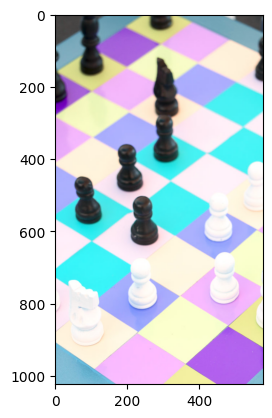

In [2]:
import cv2 as cv
import sys
from matplotlib import pyplot as plt
import numpy as np

def get_original_image(name):
    image = cv.imread(cv.samples.findFile(f"resources/{name}.jpg"))

    if image is None:
        sys.exit("Could not read the image.")

    return image

original_img = get_original_image("photo_1")

plt.imshow(original_img)

Harris corner detection

In [178]:
# load original image
img_with_marked_corners = get_original_image("photo_1")

# convert to gray scale
gray_img = cv.cvtColor(img_with_marked_corners, cv.COLOR_BGR2GRAY)

# convert to floating point format
gray = np.float32(gray_img)

# run harris detection
block_size = 20 # check neighborhoods of blockSize x blockSize around each pixel
kernel_size = 7 # dimensions of kernel for estimating derivatives of image
k_filter = 0.1 # filter
dst = cv.cornerHarris(gray, blockSize=block_size, ksize=kernel_size, k=k_filter)

# dilate
dst_dilated = cv.dilate(dst, np.ones((5,5),np.int8))

# keep only local maximum corners and the ones that pass the threshold
threshold = 0.1 * dst.max()
largest_in_neighbourhood = dst == dst_dilated
over_threshold = dst > threshold
corner_mask = largest_in_neighbourhood & over_threshold

# print(corner_mask)

# obtain corner coordinates
y_cords, x_cords = np.where(corner_mask)

# print([(int(x),int(y)) for x, y in zip(ys, xs)])

# sort corners according to harris evalution
corner_scores = dst[y_cords, x_cords]
top_indices = np.argsort(corner_scores)[-4:]

# print(corner_scores)
# print(np.argsort(corner_scores))
# print(corner_scores[np.argsort(corner_scores)])

top_harris_corners = list(zip(x_cords[top_indices], y_cords[top_indices]))

print(top_harris_corners)



[(np.int64(186), np.int64(423)), (np.int64(225), np.int64(568)), (np.int64(290), np.int64(129)), (np.int64(575), np.int64(121))]


SIFT corner detection

In [179]:
# load original image
img_with_marked_corners = get_original_image("photo_1")

# convert to gray scale
gray = cv.cvtColor(img_with_marked_corners, cv.COLOR_BGR2GRAY)

# detect SIFT keypoints
sift = cv.SIFT_create()
kp = sift.detect(gray, None)

# extract responses
responses = np.array([k.response for k in kp])

# sort keypoints by response, strongest first
kp_sorted = sorted(kp, key=lambda k: k.response, reverse=True)

# select top 4, but prevent overlap
top_sift_corners = []
min_distance = 30


for keypoint in kp_sorted:
    x, y = keypoint.pt

    is_far_enough = True

    # check if it's not near any of previously selected corners
    for selected_keypoint in top_sift_corners:
        selected_x, selected_y = selected_keypoint.pt

        distance = np.sqrt((x - selected_x) ** 2 + (y - selected_y) ** 2)

        if distance < min_distance:
            is_far_enough = False
            break

    if is_far_enough:
        top_sift_corners.append(keypoint)

    if len(top_sift_corners) == 4:
        break

top_sift_corners = [(int(keypoint.pt[0]), int(keypoint.pt[1])) for keypoint in top_sift_corners]

print(top_sift_corners)


[(246, 604), (91, 545), (79, 478), (198, 391)]


mark top 4 corners for each method

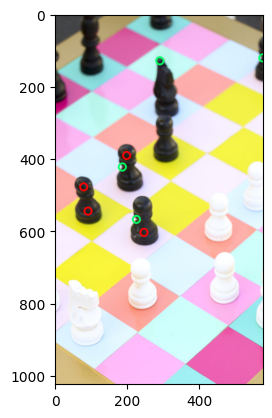

In [184]:
img_with_marked_corners = get_original_image("photo_1")

# mark top 4 corners for harris
for x, y in top_harris_corners:
    cv.circle(img_with_marked_corners, (x, y), radius=10, color=(100, 255, 0), thickness=3)

# mark top 4 corners for sift
for x, y in top_sift_corners:
    cv.circle(img_with_marked_corners, (x, y), radius=10, color=(0, 0, 255), thickness=3)

plt.imshow(cv.cvtColor(img_with_marked_corners, cv.COLOR_BGR2RGB))
plt.show()

Program 2

Perform feature matching using images photo_2_query.jpg and photo_2_train.jpg.

Draw the "good" image matches and the outline of the query image in the train image.

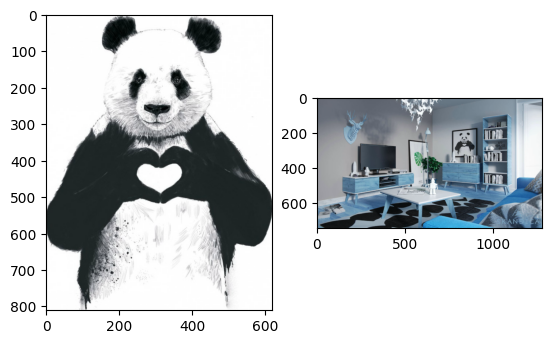

In [183]:
img_q = get_original_image("photo_2_query")
img_t = get_original_image("photo_2_train")

fig, (ax1, ax2) = plt.subplots(1,2)

ax1.imshow(img_q)
ax2.imshow(img_t)

plt.show()

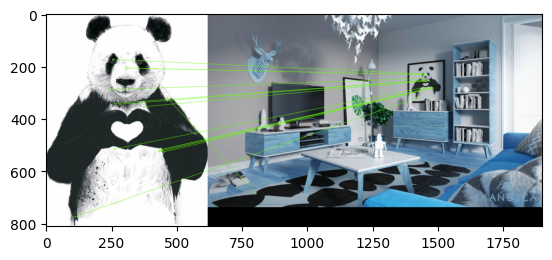

In [217]:
# cast to gray scale
query_img_gray = cv.cvtColor(img_q, cv.COLOR_BGR2GRAY)
train_img_gray = cv.cvtColor(img_t, cv.COLOR_BGR2GRAY)

# Initiate SIFT detector
sift = cv.SIFT_create()

# find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(query_img_gray,None)
kp2, des2 = sift.detectAndCompute(train_img_gray,None)

# BFMatcher with default params
bf = cv.BFMatcher()
matches = bf.knnMatch(des1,des2,k=2)

# filter poor matches
good = []
for m,n in matches:
    if m.distance < 0.6*n.distance:
        good.append([m])

# take top X matches
good_matches = [m[0] for m in good]
good_matches = sorted(good_matches, key=lambda match: match.distance)
good_matches = good_matches[:15]

good = [[m] for m in good_matches]

# mark matches
img3 = cv.drawMatchesKnn(img_q,
                        kp1,
                        img_t,
                        kp2,
                        good,
                        None,
                        matchColor=(100, 255, 0),
                        singlePointColor=(0, 0, 255),
                        flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.imshow(img3)
plt.show()